In [ ]:
from datasets import load_dataset
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, ConfusionMatrixDisplay, confusion_matrix

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    PolynomialFeatures,
    FunctionTransformer,
)

from scipy.signal import welch

c:\Users\ASUS\Downloads\workshop2_ia\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Definamos el "random_state" para que los resultados sean reproducibles:
random_state=42

# Análisis preliminar

## 1.0 Dataset loading:

In [3]:
# Carga el dataset:
data = load_dataset('YominE/Muscle_Fatigue_Cycling')
print(data)

# Conversion a dataframe de pandas para mejor visualización
df = data['train'].to_pandas()
print(df.head())

# Tamaño de dataset
print(f'Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas\n')

DatasetDict({
    train: Dataset({
        features: ['Time', 'Right Rectus femoris', 'Left Gluteus maximus', 'Left Gastrocnemius medialis', 'Left Semitendinosus', 'Left Biceps femoris caput longus', 'Right Vastus medialis', 'Right Tibialis anterior', 'Left Gastrocnemius lateralis', 'Target'],
        num_rows: 3002137
    })
})
    Time  Right Rectus femoris  Left Gluteus maximus  \
0  0.000             -0.000264             -0.000015   
1  0.001             -0.001002             -0.000045   
2  0.002             -0.002173             -0.000034   
3  0.003             -0.002676              0.000185   
4  0.004             -0.000844              0.000785   

   Left Gastrocnemius medialis  Left Semitendinosus  \
0                     0.000344             0.000108   
1                     0.001342             0.000429   
2                     0.002944             0.001133   
3                     0.003504             0.002319   
4                     0.000426             0.003950   

 

In [4]:
# Revisa tipos de datos y valores nulos:
print('=== Tipos de datos y nulos ===')
info = pd.DataFrame({
    'dtype': df.dtypes,
    'nulos': df.isnull().sum(),
    '% nulos': (df.isnull().mean() * 100).round(2)
})
print(info)

=== Tipos de datos y nulos ===
                                    dtype  nulos  % nulos
Time                              float64      0      0.0
Right Rectus femoris              float64      0      0.0
Left Gluteus maximus              float64      0      0.0
Left Gastrocnemius medialis       float64      0      0.0
Left Semitendinosus               float64      0      0.0
Left Biceps femoris caput longus  float64      0      0.0
Right Vastus medialis             float64      0      0.0
Right Tibialis anterior           float64      0      0.0
Left Gastrocnemius lateralis      float64      0      0.0
Target                              int64      0      0.0


## 1.1.a Preprocessing data

In [5]:
print(f'Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas\n')
df.head()

#El tiempo se mide cada 0.001, es decir, un salto en el tiempo donde la frecuencia es 1000, las columnas son los musculos y cada dato en la columna hace referencia a las señales 
#eléctricas del musculo, los valores cercanos a 0 son poca actividad y los más cercanos a 1 es mayor actividad

# la frecuencia al ser 1000 significa que hay 1000 muestras por segundo

Dimensiones del dataset: 3,002,137 filas × 10 columnas



,Time,Right Rectus femoris,Left Gluteus maximus,Left Gastrocnemius medialis,Left Semitendinosus,Left Biceps femoris caput longus,Right Vastus medialis,Right Tibialis anterior,Left Gastrocnemius lateralis,Target
0,0.000,-0.000264,-0.000015,0.000344,0.000108,0.000182,0.000401,0.000267,-0.000236,0
1,0.001,-0.001002,-0.000045,0.001342,0.000429,0.000712,0.002234,0.001234,-0.001108,0
2,0.002,-0.002173,-0.000034,0.002944,0.001133,0.001692,0.007634,0.003457,-0.003277,0
3,0.003,-0.002676,0.000185,0.003504,0.002319,0.002820,0.017656,0.006587,-0.006940,0
4,0.004,-0.000844,0.000785,0.000426,0.003950,0.003729,0.028542,0.008889,-0.011310,0


In [6]:
# Reemplazar valores de target
df['Target'] = df['Target'].replace(2,1)
 
# Verificamos que target ahora solo contenga valor 0, 1
print(df['Target'].value_counts())

Target
0    2127600
1     874537
Name: count, dtype: int64


## 1.1.b Features clasification

In [7]:
TARGET = 'Target'

# Antes de clasificar features, separemos el target del dataset
X = df.drop(columns=[TARGET]) # Features
y = df[TARGET] # Goal

# Clasificación de features
continuous_num_cols = X.columns
print(continuous_num_cols)


Index(['Time', 'Right Rectus femoris', 'Left Gluteus maximus',
       'Left Gastrocnemius medialis', 'Left Semitendinosus',
       'Left Biceps femoris caput longus', 'Right Vastus medialis',
       'Right Tibialis anterior', 'Left Gastrocnemius lateralis'],
      dtype='str')


Explicación

Dado que todas las variables en df son numéricas, estas se pueden separar en binarias y continuas/discretas, pero la única binaria en nuestro df es la variable target, y dado que la clasificación de caracteristicas se hace sobre X, que es el df sin la feature target, el único tipo que nos queda son las numéricas continuas, que serían todas las features de X.

# Fetaures seleccionadas

## Justificación de la selección de características

Para la extracción de características a partir de las señales de electromiografía (EMG), se seleccionó un conjunto reducido pero representativo de variables que capturan diferentes dimensiones fisiológicas del comportamiento muscular durante el ejercicio. En particular, se eligieron las características **MAV (Mean Absolute Value), varianza, Zero Crossing (ZC)** y **frecuencia mediana**, ya que en conjunto permiten describir la señal tanto en el dominio del tiempo como en el de la frecuencia, evitando redundancias innecesarias y reduciendo el riesgo de sobreajuste.

- La **MAV (Mean Absolute Value)** mide el valor promedio absoluto de la señal, proporcionando una estimación directa del nivel de activación muscular. Valores altos de MAV se asocian con un mayor reclutamiento de unidades motoras, lo cual refleja el esfuerzo realizado por el músculo. Esta característica es ampliamente utilizada en el análisis de EMG debido a su simplicidad y estabilidad frente al signo de la señal.

- La **varianza** cuantifica la dispersión de los valores de la señal respecto a su media, permitiendo caracterizar la variabilidad o irregularidad del comportamiento muscular. Esta medida complementa a la MAV, ya que dos señales pueden tener niveles de activación similares pero diferir en su estructura interna. En el contexto de fatiga, una varianza alta puede indicar una señal más irregular o con cambios bruscos en la activación, lo cual puede estar asociado a compensaciones musculares o a una activación menos eficiente. Por otro lado, una varianza baja puede reflejar una señal más uniforme o “plana”, lo cual también puede aparecer en estados de fatiga avanzada donde el músculo pierde capacidad de respuesta. En este sentido, la varianza no indica fatiga de forma directa, pero sí aporta información sobre cambios en el comportamiento de la señal que ayudan al modelo a distinguir entre estados.

- El **Zero Crossing (ZC)** corresponde al número de veces que la señal cambia de signo dentro de una ventana. Más allá de ser un simple conteo, esta característica permite estimar qué tan rápido oscila la señal en el tiempo. Una señal que cambia de signo muchas veces en un intervalo corto implica que está oscilando rápidamente (es decir, tiene componentes de alta frecuencia), mientras que una señal con pocos cruces por cero cambia más lentamente (menor contenido de altas frecuencias). Por esta razón, el ZC actúa como un indicador indirecto del contenido en frecuencia sin necesidad de transformar la señal al dominio frecuencial. En el contexto de fatiga muscular, una disminución en el número de cruces por cero suele asociarse a una señal más lenta, lo cual es consistente con la reducción de componentes de alta frecuencia observada en músculos fatigados.

- La **frecuencia mediana** se define como la frecuencia que divide el espectro de potencia en dos mitades de igual energía. Esta característica es particularmente relevante en el análisis de fatiga muscular, ya que existe evidencia de que, a medida que el músculo se fatiga, el contenido espectral de la señal EMG se desplaza hacia frecuencias más bajas. Por tanto, la frecuencia mediana constituye un indicador robusto y fisiológicamente significativo del estado de fatiga.


## Exclusión de otras características

Se decidió no incluir ciertas características comúnmente utilizadas con el fin de evitar redundancia y reducir la dimensionalidad del problema.

En particular, el **RMS (Root Mean Square)** no fue considerado, ya que proporciona información muy similar a la MAV. Ambas métricas están altamente correlacionadas al medir la amplitud de la señal, por lo que incluir ambas no aportaría información adicional relevante y podría incrementar el riesgo de sobreajuste.

De manera similar, la **potencia espectral total** fue descartada debido a que su información se encuentra en gran medida representada por medidas como la varianza y la MAV, las cuales también están relacionadas con la energía de la señal.

Por otra parte, la **frecuencia media** no fue seleccionada, ya que, aunque describe el centro de masa del espectro, es más sensible a valores extremos y ruido en comparación con la frecuencia mediana. En el contexto del análisis de fatiga muscular, la frecuencia mediana resulta más robusta y confiable.


## Conclusión

El conjunto de características seleccionado permite capturar de manera equilibrada aspectos clave de la señal EMG: nivel de activación (MAV), variabilidad (varianza), dinámica temporal (ZC) y comportamiento espectral (frecuencia mediana). Esta selección busca maximizar la capacidad del modelo para discriminar entre estados de fatiga y no fatiga, manteniendo al mismo tiempo una baja redundancia y reduciendo el riesgo de sobreajuste.


In [8]:
def frecuencia_mediana(ventana, fs):
    """Función para obtener la frecuencia_mediana"""
    freqs, psd = welch(ventana, fs=fs)
    potencia_acumulada = np.cumsum(psd)
    frecuencia_media_idx = np.searchsorted(potencia_acumulada, potencia_acumulada[-1] / 2)
    
    return freqs[frecuencia_media_idx]

In [9]:
def  extract_features(ventana, fs=1000):
    """Extrae características de tiempo y frecuencia de una ventana 1D."""
    # --- Dominio del tiempo ---
    mav     = np.mean(np.abs(ventana))
    varianza = np.var(ventana)
    zcr     = np.sum(np.diff(np.sign(ventana)) != 0)

    # --- Dominio de la frecuencia ---
    freqs, psd = welch(ventana, fs=fs)
    pot_acum   = np.cumsum(psd)
    idx_median = np.searchsorted(pot_acum, pot_acum[-1] / 2)
    frec_mediana = freqs[idx_median]

    return [mav, varianza, zcr, frec_mediana]

In [10]:
print(len(df))

3002137


In [11]:
""" Creamos nuevo dataframe agrupando 1000 filas del viejo df, en 1 sola, esto lo hacemos guardando información
especifica (features como mav, etc) de esas filas, en una sola, que contenga las features de todos los musculos """
# las ventanas nos permiten tener en un espacio de tiempo de 1 segundo agrupar 1000 datos de todos los musculos 

fs = 1000
windows_size = fs  # como habiamos dicho entonces 1 segundo = 1000  datos 
channels = [col for col in df.columns if col not in ["Time", "Target"]] # channels son las columnas del viejo datatset (los musculos)
rows = [] # contendrá todas las row del dataframe nuevo, 1 row serían las 32 features en 1s 

for i in range(0, len(df) - windows_size, windows_size): #creamos el ciclo que recorre todas las señales (datos) y lo corta en las ventanas que queremos 
    # contiene todos los musculos en 1s de dataset viejo
    window_df = df.iloc[i:i+windows_size]  # contiene una ventana del dataset viejo, treyendo todos los musculos en ese i.

    row = {} # contendrá fila de los 8 musculos, con sus 4 features
    for channel in channels:  # recorremos los musculos
        signals = window_df[channel].values  # tomamos las 1000 señales de una columna en especifico
        features = extract_features(signals, fs)

        features_names = ['mav', 'var', 'zcr', 'f_mediana']

        for name,value in zip(features_names, features):
            row[f'{channel}_{name}'] = value

    #se le caclula las 4 features a los 8 musculos, y se guardan -> al final cada ventana es una fila y cada musculo pone varias columnas de cada feature
    # como en cada ventana se arupan 1000 filas entonces se debe definir un solo target para la ventana, este se saca con la moda 
    row['target'] = window_df['Target'].mode()[0]

    rows.append(row)  #cada fiila de feature es una ventana con las 4 caracteristicas de cada uno de los 8 musculos 

# nuevo dataset
df_with_features = pd.DataFrame(rows)

#print("nuevo dataframe")
print(df_with_features.head())  #se crea el dataset pero ya estructurado con la info dada en las caracteristicas/features




   Right Rectus femoris_mav  Right Rectus femoris_var  \
0                  0.008125                  0.000137   
1                  0.010118                  0.000197   
2                  0.010151                  0.000220   
3                  0.009894                  0.000191   
4                  0.009676                  0.000177   

   Right Rectus femoris_zcr  Right Rectus femoris_f_mediana  \
0                       123                        50.78125   
1                       111                        54.68750   
2                       121                        46.87500   
3                       121                        46.87500   
4                       122                        46.87500   

   Left Gluteus maximus_mav  Left Gluteus maximus_var  \
0                  0.003260                  0.000016   
1                  0.003398                  0.000018   
2                  0.003354                  0.000018   
3                  0.003532                  0.000

In [12]:
print(len(df_with_features))

3002


# 3.0 Analisis exploratorio de datos 

## Distribuciones de variables y estadísticos descriptivos

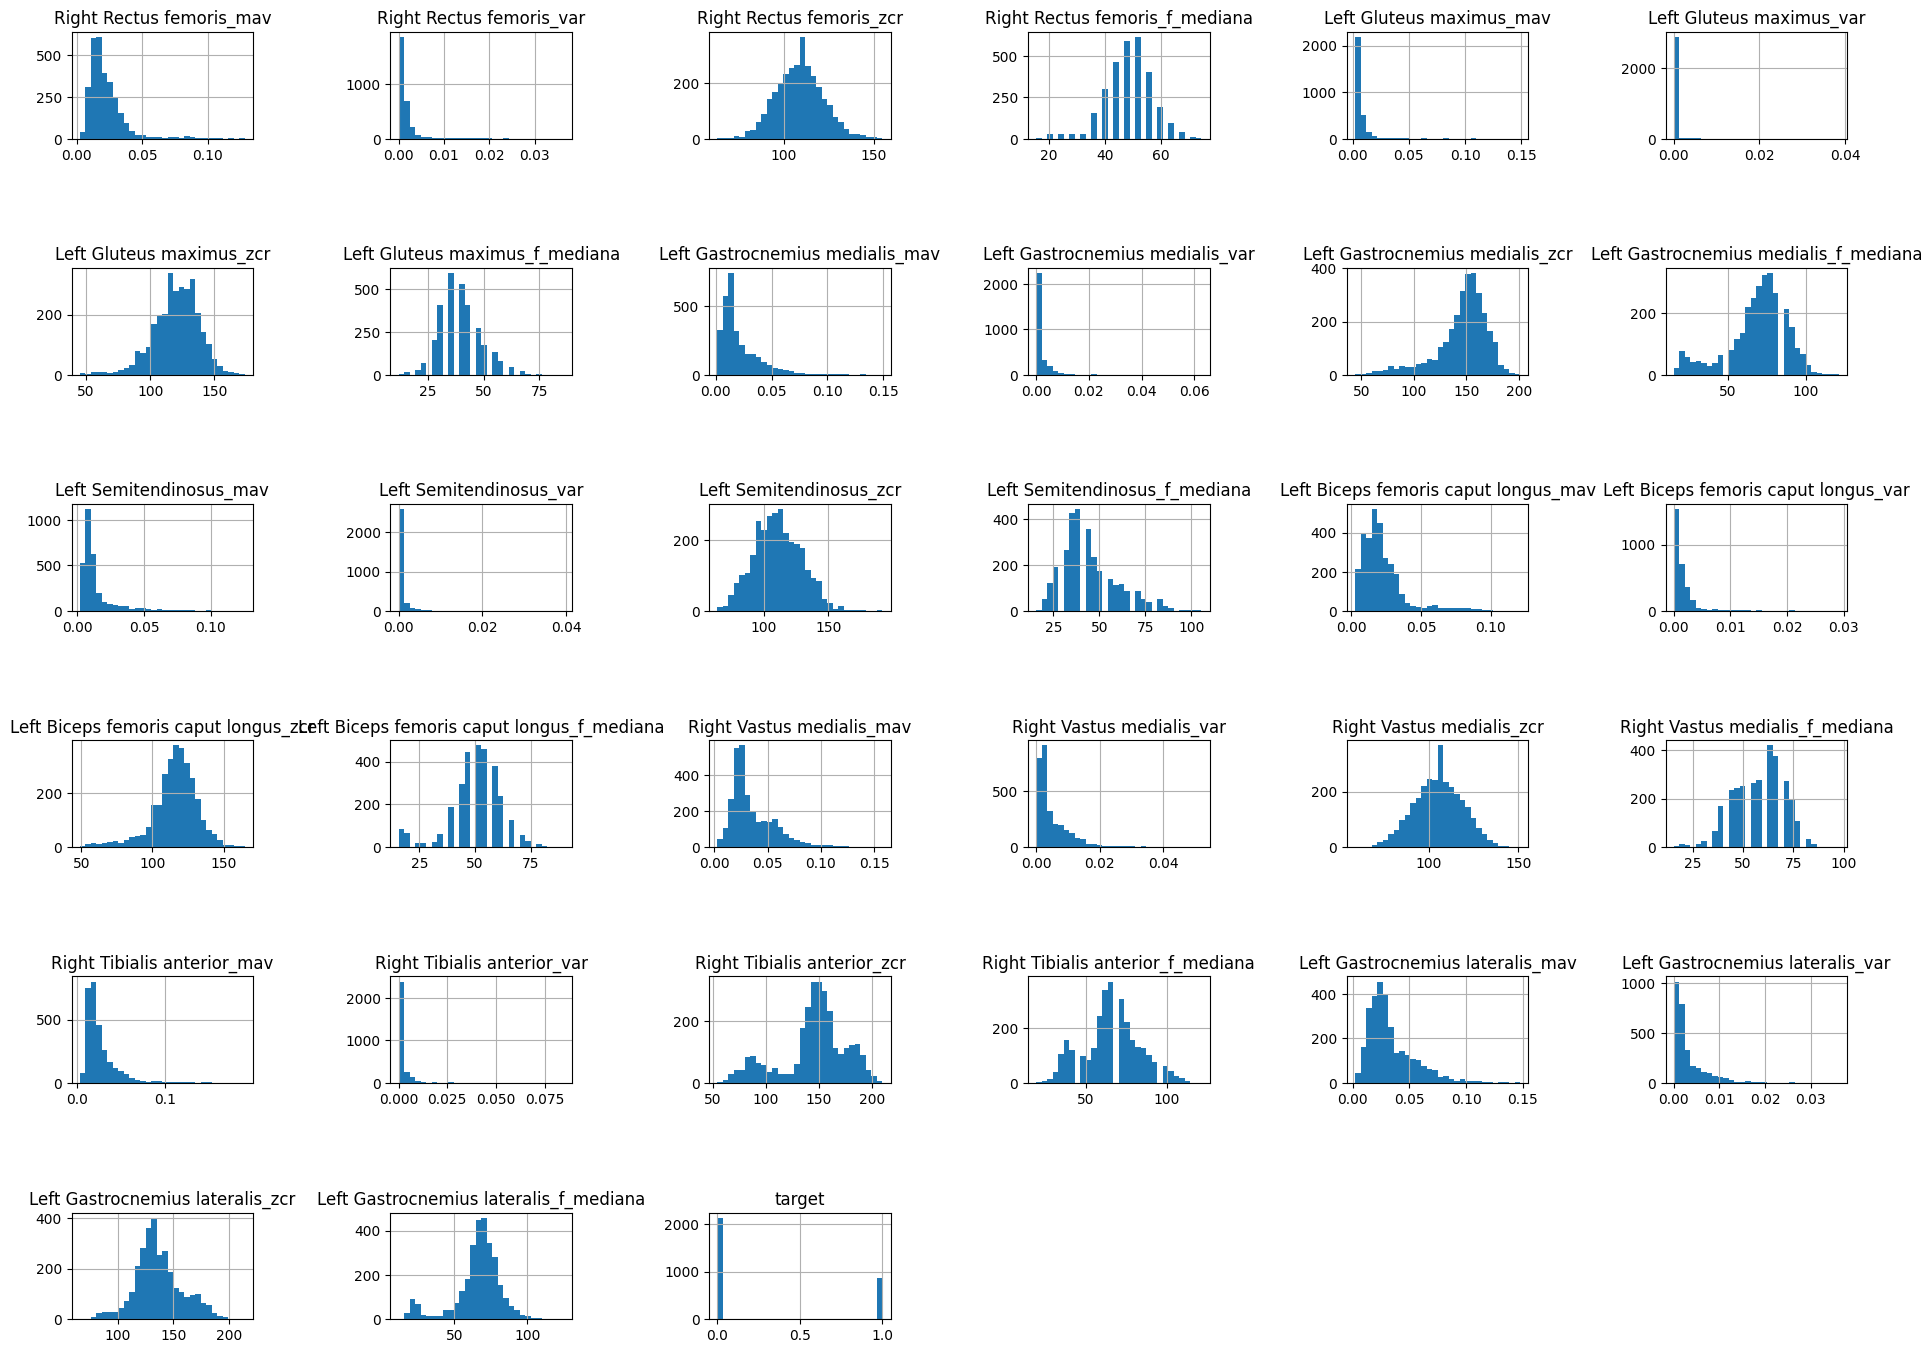

In [13]:
"""Distribuciones de variables"""
# df_with_features.hist(bins=30, figsize=(20, 15));

# Histogramas de cada característica en cada musculo 
df_with_features.hist(figsize=(20,15), bins=30)
plt.tight_layout(pad=6.0)
plt.show()


## Histogramas: Distribución de las Variables

Las variables correspondientes al **MAV**, como *Right Rectus Femoris_mav*, presentan distribuciones inclinadas o sesgadas hacia la derecha. Esto indica que la mayoría de las ventanas tienen niveles bajos de activación muscular, lo que sugiere que los músculos permanecen la mayor parte del tiempo en estados de reposo o actividad moderada, con incrementos puntuales cuando el esfuerzo físico aumenta.

Por otro lado, las variables de **varianza** muestran valores muy pequeños y distribuciones concentradas cerca de cero. Esto evidencia que, en general, la señal es relativamente estable y no presenta grandes fluctuaciones en la mayoría de las ventanas. Sin embargo, en ciertos casos se observan incrementos en la varianza, lo que puede estar relacionado con cambios en el patrón de activación muscular, especialmente en situaciones de fatiga o esfuerzo elevado.

En el caso del **ZCR** (*Zero Crossing Rate*), se puede observar una distribución más centrada y con forma cercana a una campana, con valores entre 80 y 150. Esto indica que la señal tiene una frecuencia estable en el tiempo. Esta característica resulta importante, ya que un mayor número de cruces por cero está asociado a señales más rápidas, es decir, menor fatiga, mientras que un menor número indica señales más lentas, lo cual se relaciona con fatiga muscular. De esta manera, el modelo cuenta con variabilidad suficiente para encontrar patrones tomando esta variable como referencia.

Respecto a la **frecuencia mediana**, las variables presentan distribuciones más simétricas, concentradas en rangos específicos entre 40 y 80. Esta característica puede ayudar a identificar un patrón en el que, a medida que el músculo se fatiga, la señal se desplaza hacia frecuencias más bajas. Por lo tanto, la variabilidad observada en esta medida resulta útil para diferenciar entre estados musculares.

Finalmente, al analizar el *target*, se observa un desbalance entre clases, con una mayor proporción de muestras en la clase 0. Este desbalance puede afectar el rendimiento de los modelos a utilizar, ya que existe el riesgo de que el modelo aprenda solo la clase mayoritaria.


In [14]:
"""Estadisticos descriptivos"""

# Columna -> característia de un músculo
# Fila -> medida estadística como mean, std, min
# count -> cuantos datos hay, mean -> promedio, std -> que tanto varian esos datos
# min -> el valor minimo 25% -> valor bajo tipico, 50% -> es la mediana, 75% -> valor alto típico y max -> el valor maximo 
df_with_features.describe()

,Right Rectus femoris_mav,Right Rectus femoris_var,Right Rectus femoris_zcr,Right Rectus femoris_f_mediana,Left Gluteus maximus_mav,Left Gluteus maximus_var,Left Gluteus maximus_zcr,Left Gluteus maximus_f_mediana,Left Gastrocnemius medialis_mav,Left Gastrocnemius medialis_var,...,Right Vastus medialis_f_mediana,Right Tibialis anterior_mav,Right Tibialis anterior_var,Right Tibialis anterior_zcr,Right Tibialis anterior_f_mediana,Left Gastrocnemius lateralis_mav,Left Gastrocnemius lateralis_var,Left Gastrocnemius lateralis_zcr,Left Gastrocnemius lateralis_f_mediana,target
count,3002.000000,3002.000000,3002.000000,3002.000000,3002.000000,3002.000000,3002.000000,3002.000000,3002.000000,3002.000000,...,3002.000000,3002.000000,3002.000000,3002.000000,3002.000000,3002.000000,3002.000000,3002.000000,3002.000000,3002.000000
mean,0.022596,0.001869,108.874084,47.493078,0.008064,0.000452,120.347435,39.560866,0.022297,0.002191,...,57.818225,0.028088,0.003252,144.653231,65.966439,0.033773,0.003512,136.696536,65.930005,0.291139
std,0.015262,0.003613,13.094489,8.368634,0.012312,0.002460,17.927588,9.437805,0.019188,0.004744,...,12.533601,0.022730,0.007646,31.409157,17.563901,0.021429,0.004391,21.512134,16.929977,0.454363
min,0.002243,0.000009,63.000000,15.625000,0.002164,0.000008,45.000000,11.718750,0.001680,0.000005,...,15.625000,0.003194,0.000017,54.000000,19.531250,0.002030,0.000008,66.000000,11.718750,0.000000
25%,0.013461,0.000465,100.000000,42.968750,0.004019,0.000029,110.000000,35.156250,0.010757,0.000262,...,46.875000,0.015058,0.000510,135.000000,54.687500,0.019164,0.000859,124.000000,62.500000,0.000000
50%,0.018516,0.000885,109.000000,46.875000,0.005004,0.000049,122.000000,39.062500,0.015276,0.000584,...,58.593750,0.020727,0.000924,149.000000,66.406250,0.027592,0.001867,134.000000,66.406250,0.000000
75%,0.026945,0.001778,118.000000,50.781250,0.007427,0.000119,133.000000,42.968750,0.028527,0.002229,...,66.406250,0.031982,0.002194,163.000000,78.125000,0.043840,0.004423,148.000000,74.218750,1.000000
max,0.128436,0.036360,155.000000,74.218750,0.148809,0.038583,174.000000,85.937500,0.149116,0.062701,...,97.656250,0.189659,0.084734,210.000000,121.093750,0.147630,0.036155,214.000000,125.000000,1.000000


## Estadísticas Descriptivas por Variable y Músculo

De las variables en cada músculo, podemos observar que:

- **MAV:** el promedio es bajo, lo que indica que la mayor parte del tiempo la actividad es moderada. En los valores máximos existe diferencia con respecto al promedio, por lo que pueden presentarse picos de activación. Esto puede ayudar al modelo a diferenciar entre el estado normal y el de fatiga.

- **Varianza:** los valores promedio son en su mayoría muy pequeños, y la cantidad máxima puede mostrar momentos donde la señal es irregular. Esta variabilidad puede ser importante para detectar cambios en el comportamiento muscular.

- **ZCR:** es más estable, moviéndose entre 100 y 150, por lo que la frecuencia de la señal se mantiene estable en estos rangos, lo que le permite al modelo saber en qué valores se mueve normalmente esta variable. Mientras tanto, la frecuencia mediana se distribuye en rangos de 40 y 80, distribuyéndose entre distintas ventanas.

Como se puede observar, existe una variabilidad importante en los valores extremos y distribuciones no uniformes, por lo que contamos con datos relevantes para diferenciar entre clases. Además, a partir del comportamiento de los datos, se pueden intuir picos de actividad, cambios en la frecuencia y variaciones en la señal que pueden estar asociados a estados de fatiga. Aun así, el desbalance en la variable objetivo, como se verá en las gráficas siguientes, nos da pie a evaluar técnicas para trabajar sobre esta característica de la base de datos.

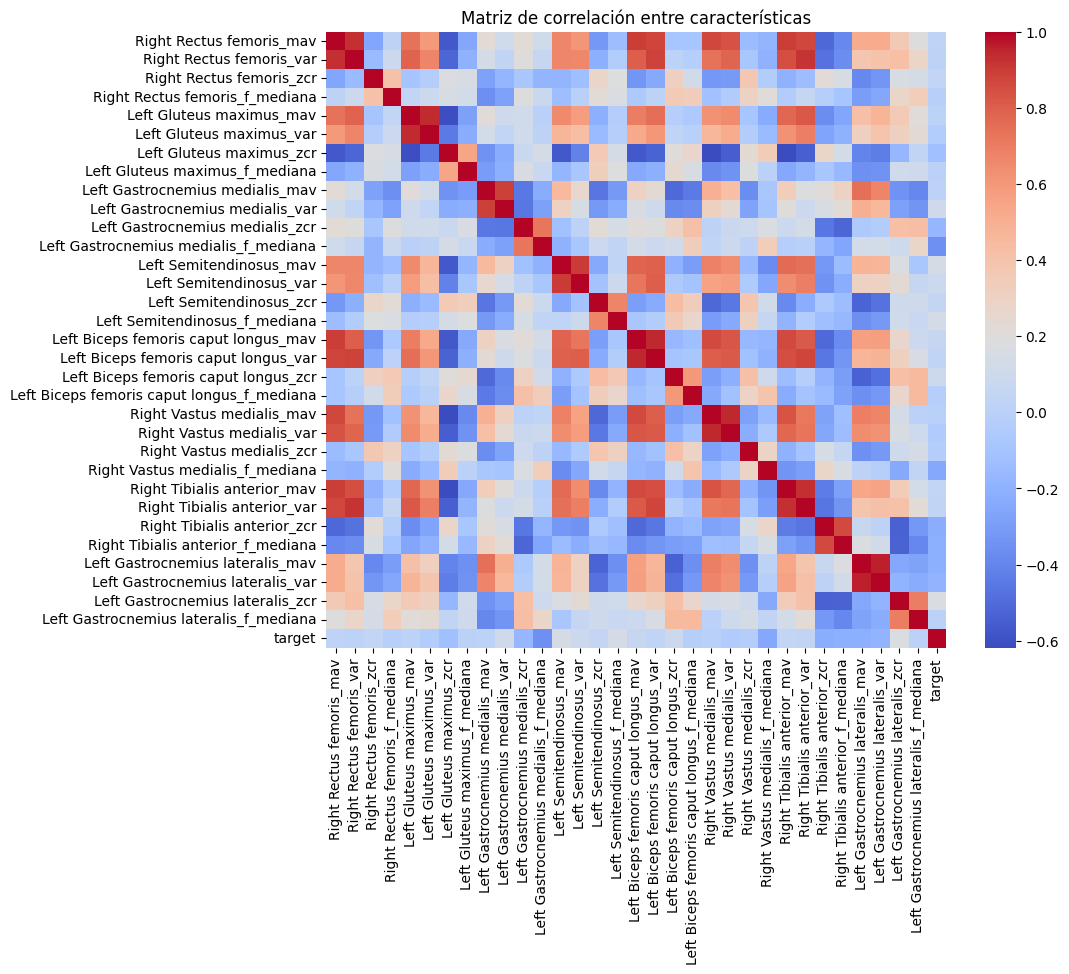

In [15]:
"""Correlaciones entre caracteristicas"""
corr_matrix = df_with_features.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Matriz de correlación entre características")
plt.show()

## Matriz de Correlación

Se observa que en la diagonal principal aparecen valores rojos intensos, lo cual es esperado, ya que cada variable está perfectamente correlacionada consigo misma. Más allá de esto, se identifican bloques de color rojo entre características del mismo tipo dentro de un mismo músculo, por ejemplo, entre variables como **MAV** y **varianza** en músculos como *Right Rectus Femoris*, *Left Gluteus Maximus* y *Right Tibialis Anterior*. Esto indica que estas características están relacionadas entre sí y pueden contener información redundante. También se observa que algunas características de diferentes músculos presentan correlaciones moderadas, lo que sugiere que existe cierta sincronización o comportamiento similar entre grupos musculares durante la actividad física.

Por otro lado, la mayoría de las celdas presentan colores claros, lo que indica que muchas variables no están fuertemente correlacionadas entre sí. Esto es positivo, ya que sugiere que las características aportan información complementaria y enriquecen el modelo. En cuanto a la relación con el *target*, se observa que los valores de correlación son en su mayoría bajos o moderados (colores claros o ligeramente rojizos), lo que indica que ninguna característica individual es suficiente para explicar completamente el estado de fatiga muscular. Esto sugiere que el problema no es trivial y que es necesario utilizar modelos que combinen múltiples variables para lograr una buena clasificación.

En conclusión, la matriz de correlación evidencia la existencia de cierta redundancia entre algunas características, pero también muestra que la mayoría aporta información útil. Además, confirma que la detección de fatiga muscular depende de patrones complejos en los datos y no de una sola variable. De igual forma, se puede observar que no existe una correlación alta entre una sola característica y el *target*, lo que indica que la detección de fatiga no depende de una única variable, sino de la combinación de varias.

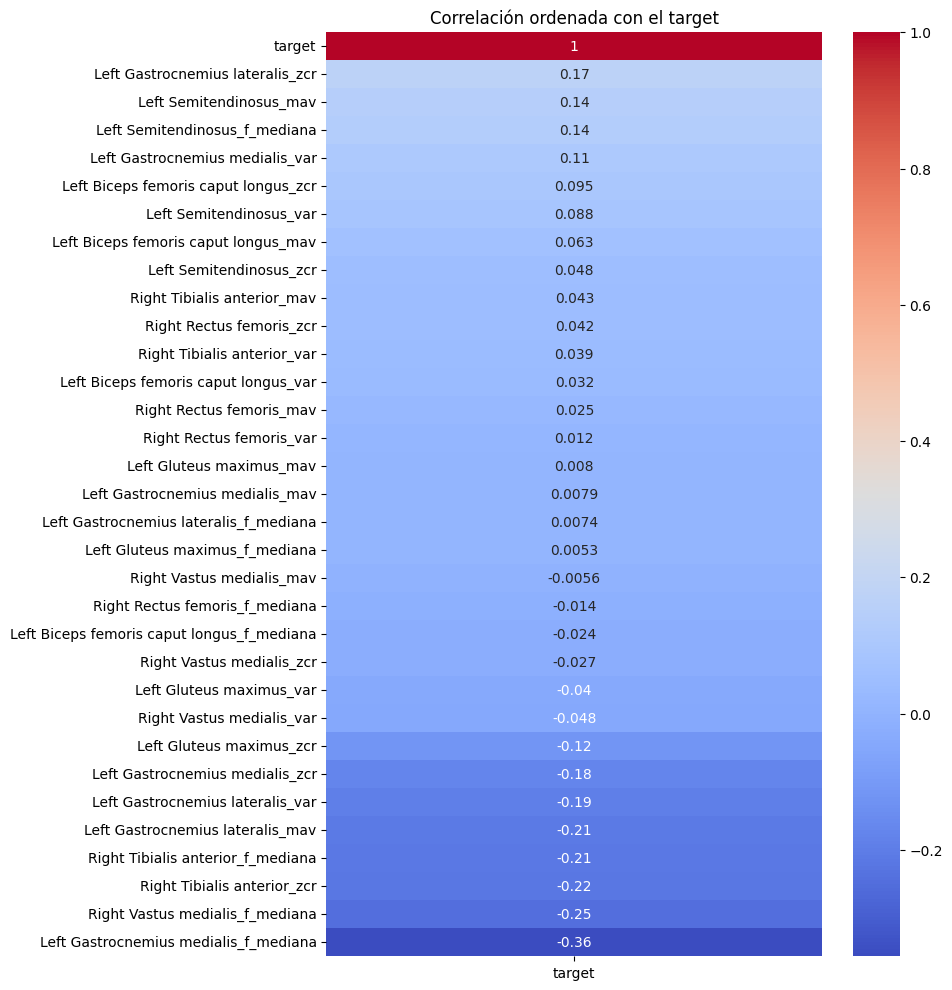

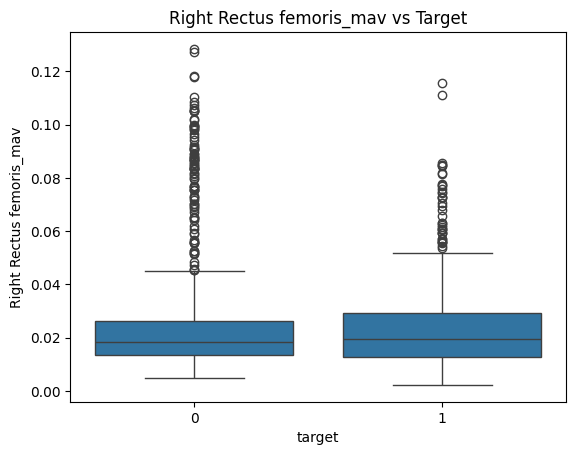

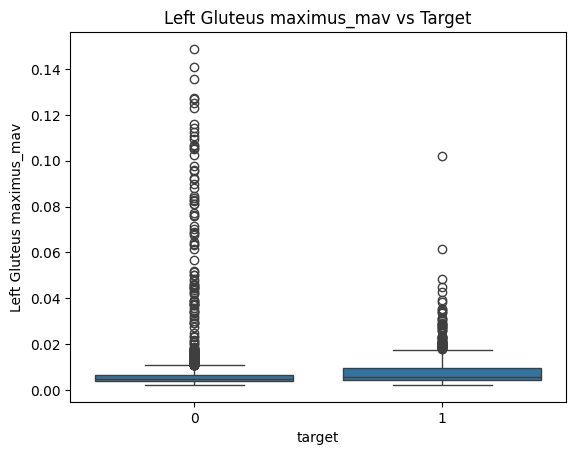

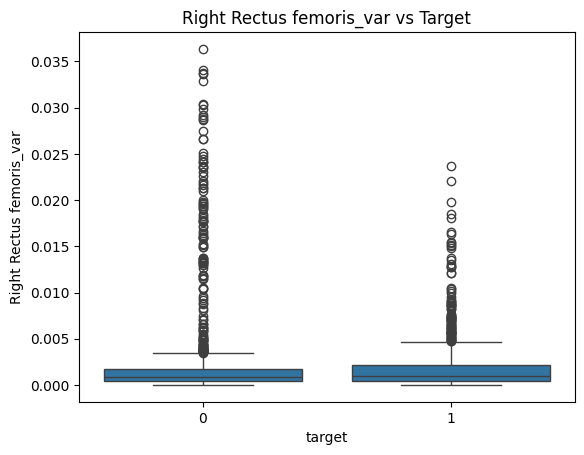

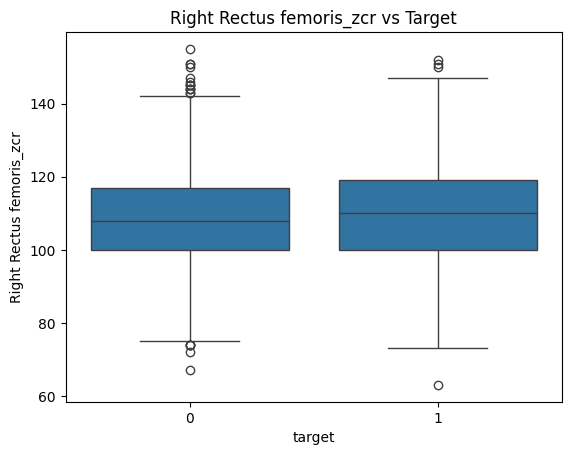

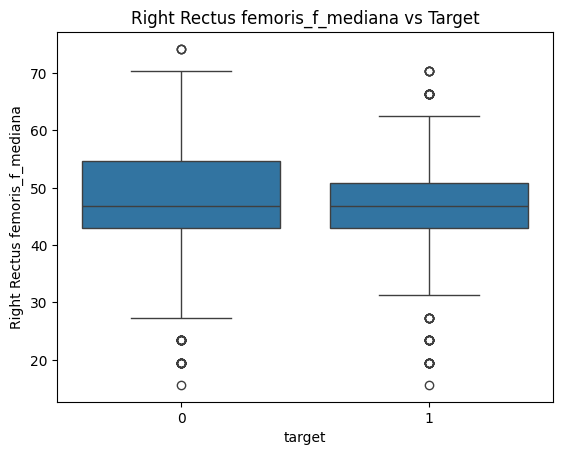

In [16]:
"""Relación entre características y el target"""

corr_target = corr_matrix['target'].sort_values(ascending=False)

plt.figure(figsize=(8, 12))
sns.heatmap(corr_target.to_frame(), annot=True, cmap='coolwarm')
plt.title("Correlación ordenada con el target")
plt.show()

#-----------------------------
# Boxplots y separabilidad 

features = [
    'Right Rectus femoris_mav',
    'Left Gluteus maximus_mav',
    'Right Rectus femoris_var',
    'Right Rectus femoris_zcr',
    'Right Rectus femoris_f_mediana'
]

for f in features:
    sns.boxplot(x='target', y=f, data=df_with_features)
    plt.title(f"{f} vs Target")
    plt.show()


## Primera Gráfica: Correlación entre Features y Target

En la primera gráfica se pueden observar las correlaciones entre las *features* y el *target*. Características como **ZRC** y **MAV**, es decir, aquellas que capturan cambios en la intensidad de la señal, presentan los valores más altos de correlación, lo que indica que están más relacionadas con el *target*. Esto sugiere que estas variables pueden contener información relevante para diferenciar entre estados de fatiga y condición normal.

Sin embargo, todos los valores se encuentran más cercanos a 0 que a 1, lo que indica que ninguna variable aporta suficiente información de manera individual. No obstante, resultan útiles cuando se analizan de manera conjunta.

## Boxplots: Análisis de Features por Clase

### MAV (Mean Absolute Value)

En el primer boxplot se puede observar que variables como **MAV** presentan una diferencia muy pequeña en la mediana entre ambas clases. En este músculo en específico, la clase asociada a fatiga muestra valores medianos ligeramente superiores, lo cual refleja un incremento en el nivel de activación muscular. Este comportamiento es ideal, ya que durante la fatiga el músculo puede requerir un mayor uso de unidades motoras, como podemos ver en las señales eléctricas necesarias para mantener el esfuerzo. Aun así, se evidencia una alta superposición entre ambas clases, tanto por la similitud en sus medianas como por la cercanía entre las cajas, lo que indica que esta característica, por sí sola, no permite una separación clara entre el *target* 0 y 1.

### Varianza

En cuanto a la varianza, podemos evidenciar que los valores se concentran fuertemente cerca de cero, con cajas pequeñas y presencia de algunos valores atípicos. Esto indica que, en la mayoría de las ventanas, la señal muscular es relativamente estable en este músculo en específico, aunque existen momentos puntuales donde la variabilidad aumenta, evidenciada por el tamaño de las cajas. No obstante, la similitud en la distribución de esta característica entre ambas clases señala que su capacidad para separar fatiga y no fatiga de manera individual es muy limitada, como habiamos evidenciado en las gráfias antriores. Sin embargo, los valores extremos visibles en la gráfica aportan información adicional, ya que podrían corresponder a eventos de activación intensa o cambios bruscos en el patrón muscular.

### ZCR (Zero Crossing Rate)

En el *Zero Crossing Rate* (ZCR) se aprecia una pequeña disminución en la mediana para la clase de fatiga en este músculo, tendencia que se mantiene en los demás. Aunque, como se ha visto en el análisis de los histogramas, esto es toericamente válido y correcto, la superposición entre las cajas de ambas clases sigue siendo muy similar, lo que de nuevo indica que esta variable no tiene gran capacidad para mostrar una separación del *target* por sí sola.

### Frecuencia Mediana

Con la frecuencia mediana se puede observar una reducción en los valores de esta *feature* para el *target* de fatiga, de lo cual se puede inferir que las señales tienden a desplazarse hacia frecuencias más bajas cuando el músculo se fatiga. Esto le aporta información más relevante al modelo; sin embargo, la superposición entre clases sigue siendo considerable, por lo que tampoco resulta suficiente para clasificar de manera precisa sin el apoyo de las demás variables.

En conclusión, se puede observar que muchas de las gráficas presentan asimetría, dado que la mediana no se encuentra centrada en la caja. Esto puede indicar que los datos no siguen una distribución estable, sino que se concentran en ciertos rangos con una marcada presencia de valores extremos. Según las características vistas en clase sobre algunos modelos, este tipo de asimetría podría favorecer algoritmos más robustos como **Random Forest**. Otro aspecto a destacar es que ninguna variable individual tiene la capacidad de diferenciar totalmente entre estados de fatiga y no fatiga. Sin embargo, las diferencias observadas en variables como ZCR, frecuencia mediana y MAV permiten combinarlas para obtener información complementaria que enriquezca el poder predictivo del modelo.

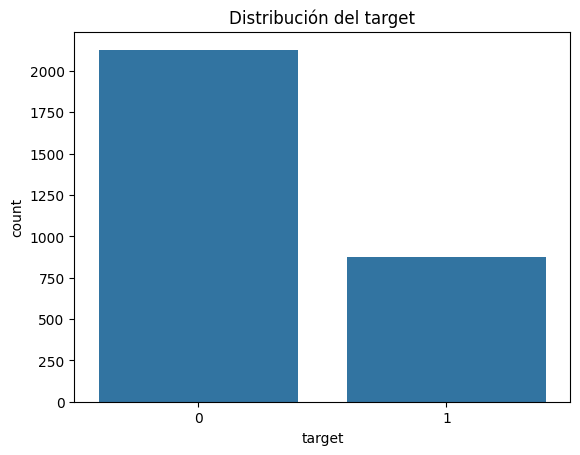

In [17]:
"""Análisis de balance de clases"""

df_with_features['target'].value_counts()
sns.countplot(x='target', data=df_with_features)
plt.title("Distribución del target")
plt.show()


## Distribución de Clases

Se puede observar que existe un desbalance de clases, donde la clase correspondiente a la condición de no fatiga presenta una mayor cantidad de muestras que la de fatiga. Esto es normal, pues los estados de condición normal suelen ser más frecuentes que los estados de fatiga. Sin embargo, para nuestro problema de clasificación, este desbalance puede sesgar el modelo hacia la clase mayoritaria. En ese contexto, un modelo podría obtener una alta precisión simplemente prediciendo la clase dominante, sin aprender realmente a identificar los casos de fatiga de manera correcta, que es el objetivo principal del problema. Esto le da prioridad al uso de modelos más robustos como **Gradient Boosting**.

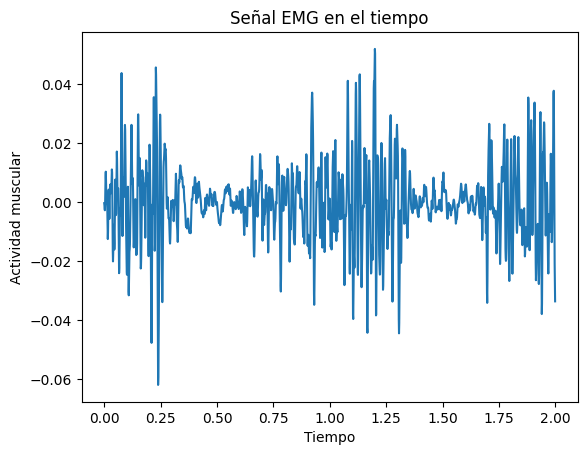

In [18]:
"""Señales en el tiempo"""

# Eje X -> tiempo de 0 a 2 seg
# Eje Y -> actividad muscular como señal eléctrica
# Cada punto en la grafica es la  medición del músculo en un instante

plt.plot(df['Time'][:2000], df['Right Rectus femoris'][:2000])
plt.title("Señal EMG en el tiempo")
plt.xlabel("Tiempo")
plt.ylabel("Actividad muscular")
plt.show()

## Señal en el Tiempo

Al observar la gráfica de la señal en el tiempo, se puede notar que la actividad muscular cambia considerablemente a lo largo de un intervalo determinado. La señal presenta numerosos picos y variaciones, lo que nos indica que la intensidad de la activación muscular no es constante.

Esto es relevante para nuestro problema de clasificación, puesto que evidencia que dentro de la señal existen diferentes patrones de comportamiento. Algunos segmentos de la gráfica presentan mayor actividad muscular que otros, lo cual podría estar relacionado con los estados que se desean clasificar y podría ayudar al modelo que usemos a aprender de manera más efectiva.

Dado que la señal es irregular y contiene demasiada información para que un modelo pueda distinguir entre clases únicamente a partir de los valores originales, es aquí donde características como **MAV**, **varianza**, **ZCR** y **frecuencia mediana** toman un papel fundamental, ya que le permiten al modelo identificar las diferencias presentes en la señal, como cambios en la amplitud o en el comportamiento general de la misma a lo largo del tiempo.

## Conclusiones del Dataset

Como conclusiones acerca de este dataset, se puede observar que contiene demasiada información en su estado crudo, por lo que las ventanas nos permiten sintetizar y obtener los datos más relevantes para el modelo. Además, existe un desbalance en el *target* debido a la cantidad de muestras de no fatiga, lo cual puede ser normal en este tipo de toma de muestras. Aun así, se debe tener en cuenta en el preprocesamiento de los datos, así como el uso de todas las características en conjunto, ya que por sí solas no son muy eficientes en el entrenamiento del modelo.

Cabe resaltar que características como el **ZCR** pueden tener comportamientos más estables, lo que puede generar distribuciones más centradas y dar lugar a patrones más sencillos de captar.

# 4.0 Procesamiento de datos

En esta seccion se deja lista la nueva base de datos para el entrenamiento de modelos. Se verifica la presencia de nulos, se separan features y target, se construyen los conjuntos `train`, `val` y `test` con proporcion 70/15/15, y se preparan los pipelines de procesamiento necesarios para los modelos clasicos y la red neuronal.
        


In [19]:
from IPython.display import display

from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, learning_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import tensorflow as tf
        


In [20]:
model_df = df_with_features.copy()

print('=== Revision de nulos en la base final ===')
print(model_df.isnull().sum().sort_values(ascending=False).head())
print(f'Total de valores nulos: {int(model_df.isnull().sum().sum())}')

X_model = model_df.drop(columns=['target'])
y_model = model_df['target'].astype(int)

print(f'\nShape de X_model: {X_model.shape}')
print('Distribucion del target en la base final:')
print(y_model.value_counts(normalize=True).rename('proporcion').round(4))


=== Revision de nulos en la base final ===
Right Rectus femoris_mav          0
Right Rectus femoris_var          0
Right Rectus femoris_zcr          0
Right Rectus femoris_f_mediana    0
Left Gluteus maximus_mav          0
dtype: int64
Total de valores nulos: 0

Shape de X_model: (3002, 32)
Distribucion del target en la base final:
target
0    0.7089
1    0.2911
Name: proporcion, dtype: float64


In [21]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.15,
    stratify=y_model,
    random_state=random_state,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.15 / 0.85,
    stratify=y_temp,
    random_state=random_state,
)

X_train_val = pd.concat([X_train, X_val], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

split_summary = pd.DataFrame(
    {
        'split': ['train', 'val', 'test'],
        'rows': [len(X_train), len(X_val), len(X_test)],
        'proportion': [len(X_train) / len(X_model), len(X_val) / len(X_model), len(X_test) / len(X_model)],
        'fatigue_rate': [y_train.mean(), y_val.mean(), y_test.mean()],
    }
)

display(split_summary.round(4))
        


,split,rows,proportion,fatigue_rate
0,train,2100,0.6995,0.2914
1,val,451,0.1502,0.2905
2,test,451,0.1502,0.2905


In [22]:
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)

model_labels = {
    'knn': 'k-Nearest Neighbors',
    'decision_tree': 'Decision Tree',
    'random_forest': 'Random Forest',
    'gradient_boosting': 'Gradient Boosting',
    'dnn': 'Deep Neural Network (DNN)',
}


def build_pipeline(model_key):
    estimators = {
        'knn': KNeighborsClassifier(),
        'decision_tree': DecisionTreeClassifier(random_state=random_state),
        'random_forest': RandomForestClassifier(random_state=random_state, n_jobs=-1),
        'gradient_boosting': GradientBoostingClassifier(random_state=random_state),
    }
    scaler = StandardScaler() if model_key == 'knn' else 'passthrough'
    return Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', scaler),
            ('model', estimators[model_key]),
        ]
    )


search_spaces = {
    'knn': {
        'model__n_neighbors': [3, 5, 7, 9, 11, 13],
        'model__weights': ['uniform', 'distance'],
        'model__metric': ['euclidean', 'manhattan'],
    },
    'decision_tree': {
        'model__max_depth': [3, 5, 7, 10, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__class_weight': [None, 'balanced'],
    },
    'random_forest': {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [None, 5, 10],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4],
        'model__class_weight': [None, 'balanced'],
    },
    'gradient_boosting': {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.03, 0.05, 0.1],
        'model__max_depth': [2, 3, 4],
        'model__subsample': [0.8, 1.0],
    },
}


def evaluate_predictions(y_true, y_pred, split_name):
    return {
        'Split': split_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
    }



def evaluate_estimator(estimator, X_data, y_data, split_name):
    predictions = estimator.predict(X_data)
    return evaluate_predictions(y_data, predictions, split_name)



def plot_learning_curve_panel(estimator, X_data, y_data, title, ax, scoring='f1'):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator,
        X_data,
        y_data,
        cv=cv_strategy,
        scoring=scoring,
        train_sizes=np.linspace(0.2, 1.0, 5),
        n_jobs=-1,
    )
    ax.plot(train_sizes, train_scores.mean(axis=1), marker='o', label='train')
    ax.plot(train_sizes, val_scores.mean(axis=1), marker='s', label='val')
    ax.set_title(title)
    ax.set_xlabel('Training samples')
    ax.set_ylabel('F1 score')
    ax.grid(alpha=0.3)
    ax.legend()
        


# 5.0 Entrenamiento y comparacion de modelos

A continuacion se entrenan los clasificadores solicitados. Para los modelos clasicos se utiliza `RandomizedSearchCV` con scoring `F1`, ya que el problema presenta desbalance de clases y esta metrica resume precision y recall de manera mas robusta que accuracy por si sola.
        


In [23]:
comparison_rows = []
model_artifacts = {}
search_diagnostics = {}

classical_model_keys = ['knn', 'decision_tree', 'random_forest', 'gradient_boosting']

for model_key in classical_model_keys:
    print(f'Entrenando y ajustando {model_labels[model_key]}...')
    pipeline = build_pipeline(model_key)
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=search_spaces[model_key],
        n_iter=10,
        scoring='f1',
        cv=cv_strategy,
        random_state=random_state,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train)

    label = model_labels[model_key]
    model_artifacts[label] = {
        'kind': 'sklearn',
        'builder_key': model_key,
        'best_params': search.best_params_,
        'best_estimator': search.best_estimator_,
    }
    search_diagnostics[label] = {
        'best_cv_f1': search.best_score_,
        'best_params': search.best_params_,
    }

    for split_name, X_split, y_split in [
        ('train', X_train, y_train),
        ('val', X_val, y_val),
        ('test', X_test, y_test),
    ]:
        metrics = evaluate_estimator(search.best_estimator_, X_split, y_split, split_name)
        metrics['Modelo'] = label
        metrics['Tipo'] = 'ML'
        metrics['Best params'] = str(search.best_params_)
        comparison_rows.append(metrics)

best_params_df = pd.DataFrame(
    [
        {
            'Modelo': model_name,
            'Best CV F1': values['best_cv_f1'],
            'Best params': values['best_params'],
        }
        for model_name, values in search_diagnostics.items()
    ]
).sort_values('Best CV F1', ascending=False)

display(best_params_df)
        


Entrenando y ajustando k-Nearest Neighbors...
Entrenando y ajustando Decision Tree...
Entrenando y ajustando Random Forest...
Entrenando y ajustando Gradient Boosting...


,Modelo,Best CV F1,Best params
2,Random Forest,0.766349,"{'model__n_estimators': 200, 'model__min_sampl..."
3,Gradient Boosting,0.741266,"{'model__subsample': 0.8, 'model__n_estimators..."
0,k-Nearest Neighbors,0.718369,"{'model__weights': 'distance', 'model__n_neigh..."
1,Decision Tree,0.678121,"{'model__min_samples_split': 5, 'model__min_sa..."


In [24]:
dnn_preprocessor = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]
)

X_train_dnn = dnn_preprocessor.fit_transform(X_train)
X_val_dnn = dnn_preprocessor.transform(X_val)
X_test_dnn = dnn_preprocessor.transform(X_test)


def build_dnn(input_dim, hidden_units=(128, 64, 32), dropout_rate=0.3, l2_strength=1e-4, learning_rate=1e-3):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))
    for units in hidden_units:
        model.add(Dense(units, activation='relu', kernel_regularizer=l2(l2_strength)))
        model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='accuracy'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ],
    )
    return model



def evaluate_dnn(model, X_data, y_data, split_name):
    probabilities = model.predict(X_data, verbose=0).ravel()
    predictions = (probabilities >= 0.5).astype(int)
    metrics = evaluate_predictions(y_data, predictions, split_name)
    metrics['Prob mean'] = float(probabilities.mean())
    return metrics


rng = np.random.default_rng(random_state)
hidden_unit_options = [
    (64, 32, 16),
    (128, 64, 32),
    (128, 128, 64),
    (256, 128, 64),
]
dnn_candidates = []
for _ in range(6):
    dnn_candidates.append(
        {
            'hidden_units': hidden_unit_options[int(rng.integers(0, len(hidden_unit_options)))],
            'dropout_rate': float(rng.choice([0.2, 0.3, 0.4])),
            'l2_strength': float(rng.choice([1e-4, 5e-4, 1e-3])),
            'learning_rate': float(rng.choice([1e-3, 5e-4])),
            'batch_size': int(rng.choice([32, 64])),
        }
    )

best_dnn_model = None
best_dnn_history = None
best_dnn_config = None
best_dnn_val_f1 = -np.inf
best_dnn_epochs = None
dnn_search_rows = []

y_train_array = y_train.to_numpy()
y_val_array = y_val.to_numpy()

for idx, config in enumerate(dnn_candidates, start=1):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(random_state + idx)

    dnn_model = build_dnn(
        input_dim=X_train_dnn.shape[1],
        hidden_units=tuple(config['hidden_units']),
        dropout_rate=config['dropout_rate'],
        l2_strength=config['l2_strength'],
        learning_rate=config['learning_rate'],
    )
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    ]
    history = dnn_model.fit(
        X_train_dnn,
        y_train_array,
        validation_data=(X_val_dnn, y_val_array),
        epochs=80,
        batch_size=config['batch_size'],
        verbose=0,
        callbacks=callbacks,
    )

    val_metrics = evaluate_dnn(dnn_model, X_val_dnn, y_val_array, 'val')
    dnn_search_rows.append(
        {
            'config_id': idx,
            'hidden_units': config['hidden_units'],
            'dropout_rate': config['dropout_rate'],
            'l2_strength': config['l2_strength'],
            'learning_rate': config['learning_rate'],
            'batch_size': config['batch_size'],
            'epochs_ran': len(history.history['loss']),
            'val_accuracy': val_metrics['Accuracy'],
            'val_precision': val_metrics['Precision'],
            'val_recall': val_metrics['Recall'],
            'val_f1': val_metrics['F1'],
        }
    )

    if val_metrics['F1'] > best_dnn_val_f1:
        best_dnn_val_f1 = val_metrics['F1']
        best_dnn_model = dnn_model
        best_dnn_history = history
        best_dnn_config = config
        best_dnn_epochs = int(np.argmin(history.history['val_loss']) + 1)

dnn_search_df = pd.DataFrame(dnn_search_rows).sort_values('val_f1', ascending=False)
display(dnn_search_df)

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(random_state)
best_dnn_model = build_dnn(
    input_dim=X_train_dnn.shape[1],
    hidden_units=tuple(best_dnn_config['hidden_units']),
    dropout_rate=best_dnn_config['dropout_rate'],
    l2_strength=best_dnn_config['l2_strength'],
    learning_rate=best_dnn_config['learning_rate'],
)
best_dnn_model.fit(
    X_train_dnn,
    y_train_array,
    epochs=best_dnn_epochs,
    batch_size=best_dnn_config['batch_size'],
    verbose=0,
)

model_artifacts[model_labels['dnn']] = {
    'kind': 'dnn',
    'best_model': best_dnn_model,
    'best_config': best_dnn_config,
    'preprocessor': dnn_preprocessor,
    'best_epochs': best_dnn_epochs,
}

for split_name, X_split, y_split in [
    ('train', X_train_dnn, y_train_array),
    ('val', X_val_dnn, y_val_array),
    ('test', X_test_dnn, y_test.to_numpy()),
]:
    metrics = evaluate_dnn(best_dnn_model, X_split, y_split, split_name)
    metrics['Modelo'] = model_labels['dnn']
    metrics['Tipo'] = 'DL'
    metrics['Best params'] = str(best_dnn_config)
    comparison_rows.append(metrics)


,config_id,hidden_units,dropout_rate,l2_strength,learning_rate,batch_size,epochs_ran,val_accuracy,val_precision,val_recall,val_f1
1,2,"(256, 128, 64)",0.2,0.0010,0.0010,32,30,0.849224,0.720280,0.786260,0.751825
5,6,"(128, 128, 64)",0.3,0.0010,0.0005,32,64,0.860310,0.783333,0.717557,0.749004
3,4,"(256, 128, 64)",0.3,0.0001,0.0005,32,31,0.858093,0.776860,0.717557,0.746032
2,3,"(128, 128, 64)",0.4,0.0010,0.0005,64,80,0.860310,0.803571,0.687023,0.740741
4,5,"(128, 128, 64)",0.3,0.0001,0.0005,64,48,0.858093,0.796460,0.687023,0.737705
0,1,"(64, 32, 16)",0.4,0.0005,0.0010,32,56,0.862528,0.828571,0.664122,0.737288


In [25]:
comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df[['Modelo', 'Tipo', 'Split', 'Accuracy', 'Precision', 'Recall', 'F1', 'Best params']]
comparison_df = comparison_df.sort_values(['Split', 'F1'], ascending=[True, False]).reset_index(drop=True)

display(comparison_df.round(4))

comparison_table = comparison_df.pivot_table(
    index='Modelo',
    columns='Split',
    values=['Accuracy', 'Precision', 'Recall', 'F1'],
)
comparison_table = comparison_table.sort_index(axis=1, level=[0, 1]).round(4)

display(comparison_table)
        


,Modelo,Tipo,Split,Accuracy,Precision,Recall,F1,Best params
0,Random Forest,ML,test,0.8980,0.8512,0.7863,0.8175,"{'model__n_estimators': 200, 'model__min_sampl..."
1,Gradient Boosting,ML,test,0.8869,0.8448,0.7481,0.7935,"{'model__subsample': 0.8, 'model__n_estimators..."
2,Deep Neural Network (DNN),DL,test,0.8670,0.8257,0.6870,0.7500,"{'hidden_units': (256, 128, 64), 'dropout_rate..."
3,k-Nearest Neighbors,ML,test,0.8581,0.7769,0.7176,0.7460,"{'model__weights': 'distance', 'model__n_neigh..."
4,Decision Tree,ML,test,0.7494,0.5429,0.8702,0.6686,"{'model__min_samples_split': 5, 'model__min_sa..."
5,k-Nearest Neighbors,ML,train,1.0000,1.0000,1.0000,1.0000,"{'model__weights': 'distance', 'model__n_neigh..."
6,Gradient Boosting,ML,train,1.0000,1.0000,1.0000,1.0000,"{'model__subsample': 0.8, 'model__n_estimators..."
7,Random Forest,ML,train,0.9938,0.9792,1.0000,0.9895,"{'model__n_estimators': 200, 'model__min_sampl..."
8,Deep Neural Network (DNN),DL,train,0.9114,0.9034,0.7794,0.8368,"{'hidden_units': (256, 128, 64), 'dropout_rate..."
9,Decision Tree,ML,train,0.8029,0.6130,0.8775,0.7218,"{'model__min_samples_split': 5, 'model__min_sa..."


Accuracy                      F1                  \
Split                         test   train     val    test   train     val   
Modelo                                                                       
Decision Tree               0.7494  0.8029  0.7561  0.6686  0.7218  0.6687   
Deep Neural Network (DNN)   0.8670  0.9114  0.8670  0.7500  0.8368  0.7500   
Gradient Boosting           0.8869  1.0000  0.8470  0.7935  1.0000  0.7229   
Random Forest               0.8980  0.9938  0.8670  0.8175  0.9895  0.7656   
k-Nearest Neighbors         0.8581  1.0000  0.8381  0.7460  1.0000  0.6920   

                          Precision                  Recall                  
Split                          test   train     val    test   train     val  
Modelo                                                                       
Decision Tree                0.5429  0.6130  0.5522  0.8702  0.8775  0.8473  
Deep Neural Network (DNN)    0.8257  0.9034  0.8257  0.6870  0.7794  0.6870  
Gradient Boosting            0.8448  1.0000  0.7627  0.7481  1.0000  0.6870  
Random Forest                0.8512  0.9792  0.7840  0.7863  1.0000  0.7481  
k-Nearest Neighbors          0.7769  1.0000  0.7736  0.7176  1.0000  0.6260

## 5.3 Curvas de entrenamiento y validacion

Para los modelos clasicos se grafican curvas de aprendizaje con `learning_curve`, y para la red neuronal se muestran las curvas por epoca del mejor experimento. Estas graficas permiten detectar sobreajuste o subajuste comparando el comportamiento entre entrenamiento y validacion.
        


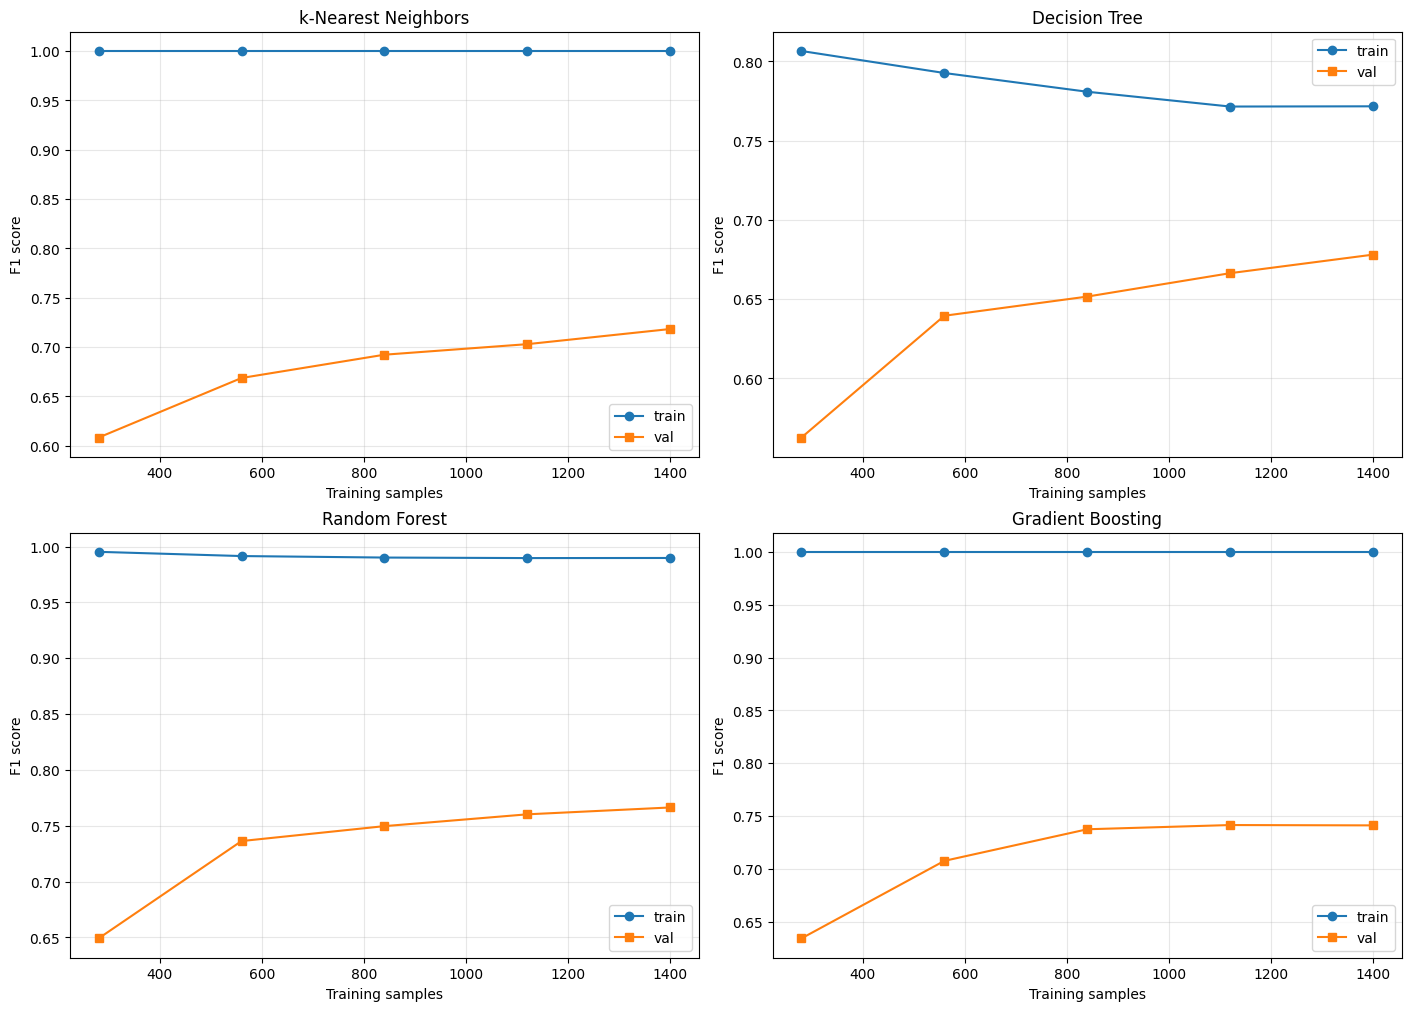

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

for ax, model_key in zip(axes.flatten(), classical_model_keys):
    estimator = model_artifacts[model_labels[model_key]]['best_estimator']
    plot_learning_curve_panel(estimator, X_train, y_train, model_labels[model_key], ax)

plt.show()
        


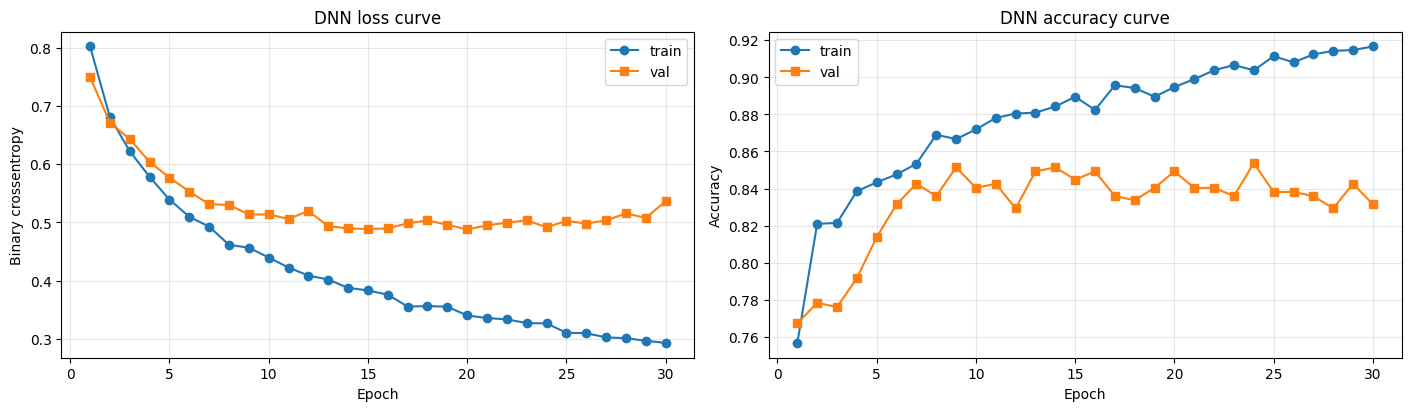

In [27]:
history_df = pd.DataFrame(best_dnn_history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
epoch_axis = np.arange(1, len(history_df) + 1)

axes[0].plot(epoch_axis, history_df['loss'], marker='o', label='train')
axes[0].plot(epoch_axis, history_df['val_loss'], marker='s', label='val')
axes[0].set_title('DNN loss curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary crossentropy')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epoch_axis, history_df['accuracy'], marker='o', label='train')
axes[1].plot(epoch_axis, history_df['val_accuracy'], marker='s', label='val')
axes[1].set_title('DNN accuracy curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.show()
        


In [28]:
train_val_gap = comparison_df[comparison_df['Split'].isin(['train', 'val'])].pivot(
    index='Modelo',
    columns='Split',
    values='F1',
)
train_val_gap['gap_train_val'] = train_val_gap['train'] - train_val_gap['val']
train_val_gap['diagnostico'] = np.where(
    train_val_gap['gap_train_val'] > 0.10,
    'Posible overfitting',
    np.where(train_val_gap['val'] < 0.60, 'Posible underfitting', 'Equilibrado'),
)

display(train_val_gap.round(4).sort_values('val', ascending=False))
        


Split,train,val,gap_train_val,diagnostico
Modelo,,,,
Random Forest,0.9895,0.7656,0.2239,Posible overfitting
Deep Neural Network (DNN),0.8368,0.7500,0.0868,Equilibrado
Gradient Boosting,1.0000,0.7229,0.2771,Posible overfitting
k-Nearest Neighbors,1.0000,0.6920,0.3080,Posible overfitting
Decision Tree,0.7218,0.6687,0.0531,Equilibrado


## 5.4 Seleccion del mejor modelo

La seleccion se hace priorizando el `F1` en validacion. En caso de empate, se desempata con `Recall` y luego con `Accuracy`, ya que detectar fatiga correctamente es mas importante que maximizar solo aciertos globales en un conjunto desbalanceado.
        


In [29]:
validation_ranking = comparison_df[comparison_df['Split'] == 'val'].sort_values(
    by=['F1', 'Recall', 'Accuracy'],
    ascending=False,
).reset_index(drop=True)

display(validation_ranking.round(4))

selected_model_name = validation_ranking.loc[0, 'Modelo']
selected_model_gap = train_val_gap.loc[selected_model_name, 'gap_train_val']
selected_model_diagnosis = train_val_gap.loc[selected_model_name, 'diagnostico']

print(f'Mejor modelo segun validacion: {selected_model_name}')
print(f'Diagnostico train/val: {selected_model_diagnosis}')
print(f'Gap F1 train-val: {selected_model_gap:.4f}')
        


,Modelo,Tipo,Split,Accuracy,Precision,Recall,F1,Best params
0,Random Forest,ML,val,0.8670,0.7840,0.7481,0.7656,"{'model__n_estimators': 200, 'model__min_sampl..."
1,Deep Neural Network (DNN),DL,val,0.8670,0.8257,0.6870,0.7500,"{'hidden_units': (256, 128, 64), 'dropout_rate..."
2,Gradient Boosting,ML,val,0.8470,0.7627,0.6870,0.7229,"{'model__subsample': 0.8, 'model__n_estimators..."
3,k-Nearest Neighbors,ML,val,0.8381,0.7736,0.6260,0.6920,"{'model__weights': 'distance', 'model__n_neigh..."
4,Decision Tree,ML,val,0.7561,0.5522,0.8473,0.6687,"{'model__min_samples_split': 5, 'model__min_sa..."


Mejor modelo segun validacion: Random Forest
Diagnostico train/val: Posible overfitting
Gap F1 train-val: 0.2239


# 6.0 Evaluacion final del mejor modelo

En esta etapa se reentrena el mejor modelo con `X_train + X_val` y se realiza la evaluacion definitiva sobre `X_test`. Luego se complementa el analisis con matriz de confusion y boxplots de variables representativas.
        


In [30]:
selected_artifact = model_artifacts[selected_model_name]
final_payload = {'model_name': selected_model_name}

y_test_array = y_test.to_numpy()

if selected_artifact['kind'] == 'sklearn':
    final_model = build_pipeline(selected_artifact['builder_key'])
    final_model.set_params(**selected_artifact['best_params'])
    final_model.fit(X_train_val, y_train_val)

    final_test_pred = final_model.predict(X_test)
    final_test_proba = final_model.predict_proba(X_test)[:, 1]

    final_payload.update(
        {
            'kind': 'sklearn',
            'model': final_model,
            'probabilities': final_test_proba,
        }
    )
else:
    final_preprocessor = Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]
    )
    X_train_val_dnn = final_preprocessor.fit_transform(X_train_val)
    X_test_final_dnn = final_preprocessor.transform(X_test)

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(random_state)
    final_model = build_dnn(
        input_dim=X_train_val_dnn.shape[1],
        hidden_units=tuple(selected_artifact['best_config']['hidden_units']),
        dropout_rate=selected_artifact['best_config']['dropout_rate'],
        l2_strength=selected_artifact['best_config']['l2_strength'],
        learning_rate=selected_artifact['best_config']['learning_rate'],
    )
    final_model.fit(
        X_train_val_dnn,
        y_train_val.to_numpy(),
        epochs=selected_artifact['best_epochs'],
        batch_size=selected_artifact['best_config']['batch_size'],
        verbose=0,
    )

    final_test_proba = final_model.predict(X_test_final_dnn, verbose=0).ravel()
    final_test_pred = (final_test_proba >= 0.5).astype(int)

    final_payload.update(
        {
            'kind': 'dnn',
            'model': final_model,
            'preprocessor': final_preprocessor,
            'probabilities': final_test_proba,
        }
    )

final_metrics = evaluate_predictions(y_test_array, final_test_pred, 'test_final')
final_metrics_df = pd.DataFrame([final_metrics]).round(4)
display(final_metrics_df)

print(classification_report(y_test_array, final_test_pred, digits=4))
        


,Split,Accuracy,Precision,Recall,F1
0,test_final,0.8869,0.8333,0.7634,0.7968


              precision    recall  f1-score   support

           0     0.9063    0.9375    0.9217       320
           1     0.8333    0.7634    0.7968       131

    accuracy                         0.8869       451
   macro avg     0.8698    0.8504    0.8592       451
weighted avg     0.8851    0.8869    0.8854       451



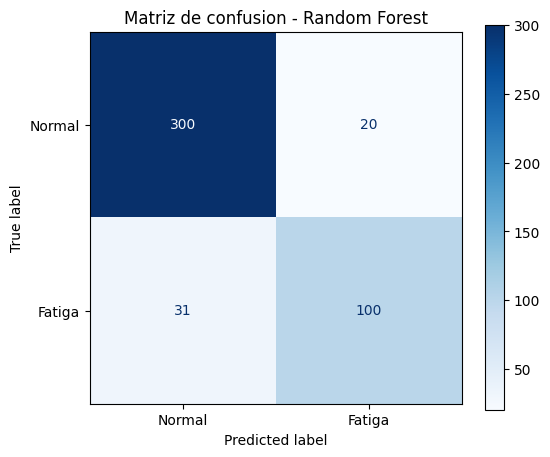

Features representativas para boxplots:
['Left Gastrocnemius medialis_f_mediana', 'Right Vastus medialis_f_mediana', 'Right Tibialis anterior_zcr', 'Right Tibialis anterior_f_mediana']


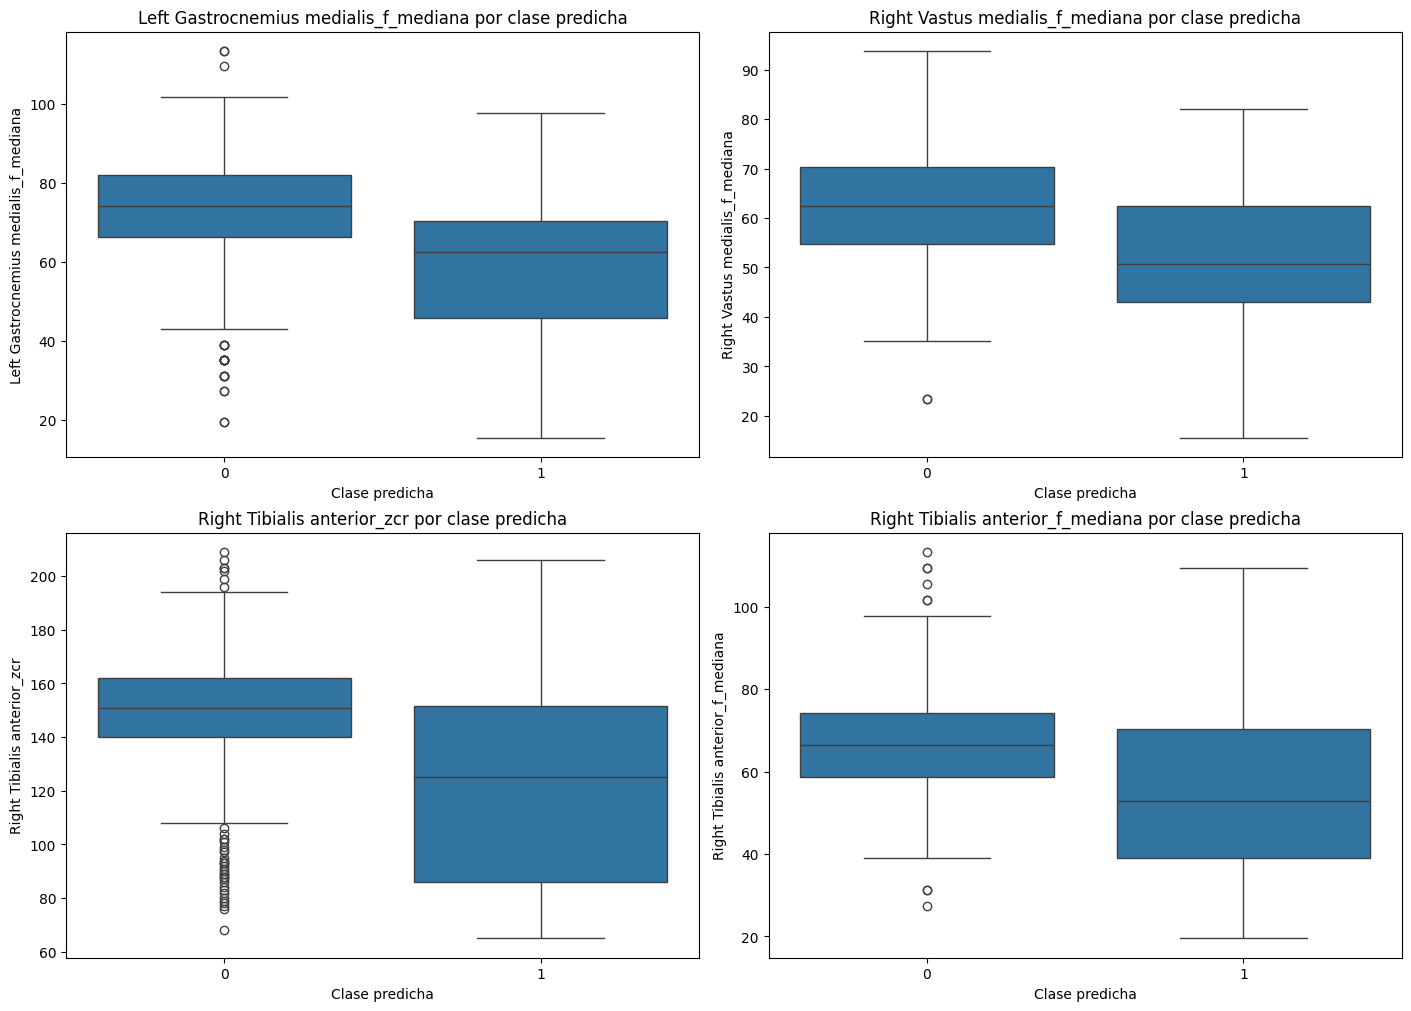

In [31]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_array,
    final_test_pred,
    display_labels=['Normal', 'Fatiga'],
    cmap='Blues',
    ax=ax,
)
ax.set_title(f'Matriz de confusion - {selected_model_name}')
plt.show()

representative_features = (
    pd.concat([X_train_val, y_train_val.rename('target')], axis=1)
    .corr(numeric_only=True)['target']
    .drop('target')
    .abs()
    .sort_values(ascending=False)
    .head(4)
    .index
    .tolist()
)

print('Features representativas para boxplots:')
print(representative_features)

test_analysis_df = X_test.copy()
test_analysis_df['target_real'] = y_test_array
test_analysis_df['target_predicho'] = final_test_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
for ax, feature in zip(axes.flatten(), representative_features):
    sns.boxplot(data=test_analysis_df, x='target_predicho', y=feature, ax=ax)
    ax.set_title(f'{feature} por clase predicha')
    ax.set_xlabel('Clase predicha')
    ax.set_ylabel(feature)

plt.show()
        


# 7.0 Prueba con muestra artificial

Se genera una muestra artificial a partir de una observacion real del conjunto de entrenamiento-validacion y se le agrega un ruido pequeno proporcional a la desviacion estandar de cada feature. De esta manera la muestra sigue siendo verosimil, pero no es una copia exacta de un registro original.
        


In [32]:
rng = np.random.default_rng(random_state)
reference_index = X_train_val.sample(1, random_state=random_state).index[0]
reference_sample = X_train_val.loc[[reference_index]].copy()
reference_label = int(y_train_val.loc[reference_index])

noise_scale = X_train_val.std().replace(0, 1) * 0.05
synthetic_sample = reference_sample + rng.normal(
    0,
    noise_scale.to_numpy(),
    size=reference_sample.shape,
)
synthetic_sample = synthetic_sample.clip(lower=0)

if final_payload['kind'] == 'sklearn':
    synthetic_probability = float(final_payload['model'].predict_proba(synthetic_sample)[:, 1][0])
    synthetic_prediction = int(final_payload['model'].predict(synthetic_sample)[0])
else:
    synthetic_transformed = final_payload['preprocessor'].transform(synthetic_sample)
    synthetic_probability = float(final_payload['model'].predict(synthetic_transformed, verbose=0).ravel()[0])
    synthetic_prediction = int(synthetic_probability >= 0.5)

synthetic_preview = synthetic_sample[representative_features].T
synthetic_preview.columns = ['valor']

display(synthetic_preview.round(4))

print(f'Clase de referencia usada para crear la muestra: {reference_label}')
print(f'Prediccion de la muestra artificial: {synthetic_prediction}')
print(f'Probabilidad estimada de fatiga: {synthetic_probability:.4f}')

if synthetic_prediction == reference_label:
    print('La prediccion tiene sentido: el modelo mantuvo la clase del patron original tras una perturbacion pequena.')
else:
    print('La prediccion no coincide con la clase base, lo que sugiere sensibilidad del modelo a pequenas variaciones de las features.')
        


,valor
Left Gastrocnemius medialis_f_mediana,71.0564
Right Vastus medialis_f_mediana,58.4966
Right Tibialis anterior_zcr,145.8333
Right Tibialis anterior_f_mediana,62.8227


Clase de referencia usada para crear la muestra: 0
Prediccion de la muestra artificial: 0
Probabilidad estimada de fatiga: 0.1738
La prediccion tiene sentido: el modelo mantuvo la clase del patron original tras una perturbacion pequena.
